In [1]:
!pip install ucimlrepo xgboost imbalanced-learn fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.2 MB/s eta 0:00:00


In [2]:
# Load and Preprocess

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load dataset
dataset = fetch_ucirepo(id=296)
df = pd.DataFrame(dataset.data.features)
df['readmitted'] = dataset.data.targets

# --- NEW FOR PROJECT 3 ---
# Store sensitive attributes BEFORE any encoding
sensitive_cols = ['race', 'gender', 'age']
df_sensitive = df[sensitive_cols].copy()

# Replace missing values in the main DataFrame
df.replace('?', np.nan, inplace=True)

# Also replace missing values in df_sensitive for consistency
df_sensitive.replace('?', np.nan, inplace=True)
# Fill NaNs in sensitive features with a distinct category 'Unknown' for fairlearn
df_sensitive.fillna('Unknown', inplace=True)
# -------------------------

# Drop high-missing columns
threshold = 0.4
cols_to_drop = [col for col in df.columns
                if df[col].isnull().mean() > threshold]
df.drop(columns=cols_to_drop, inplace=True)
df.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore', inplace=True)

# Binarise target
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

# Encode all categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Align sensitive attributes with df index
df_sensitive = df_sensitive.loc[df.index]

# Features and target
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Get sensitive attributes for test set
sensitive_test = df_sensitive.loc[X_test.index].copy()

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Train: {X_train_res.shape}, Test: {X_test_scaled.shape}")
print(f"Sensitive attributes saved: {sensitive_cols}")

Train: (144652, 43), Test: (20354, 43)
Sensitive attributes saved: ['race', 'gender', 'age']


In [3]:
# Train the model

model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss')

model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Overall AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Overall Accuracy: {(y_pred == y_test).mean():.4f}")

Overall AUC-ROC: 0.6752
Overall Accuracy: 0.8889


In [4]:
# Decode sensitive attribute labels
race_labels = le_dict['race'].classes_
gender_labels = le_dict['gender'].classes_
age_labels = le_dict['age'].classes_

print(f"Race categories: {race_labels}")
print(f"Gender categories: {gender_labels}")
print(f"Age categories: {age_labels}")

Race categories: ['AfricanAmerican' 'Asian' 'Caucasian' 'Hispanic' 'Other' 'nan']
Gender categories: ['Female' 'Male' 'Unknown/Invalid']
Age categories: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']


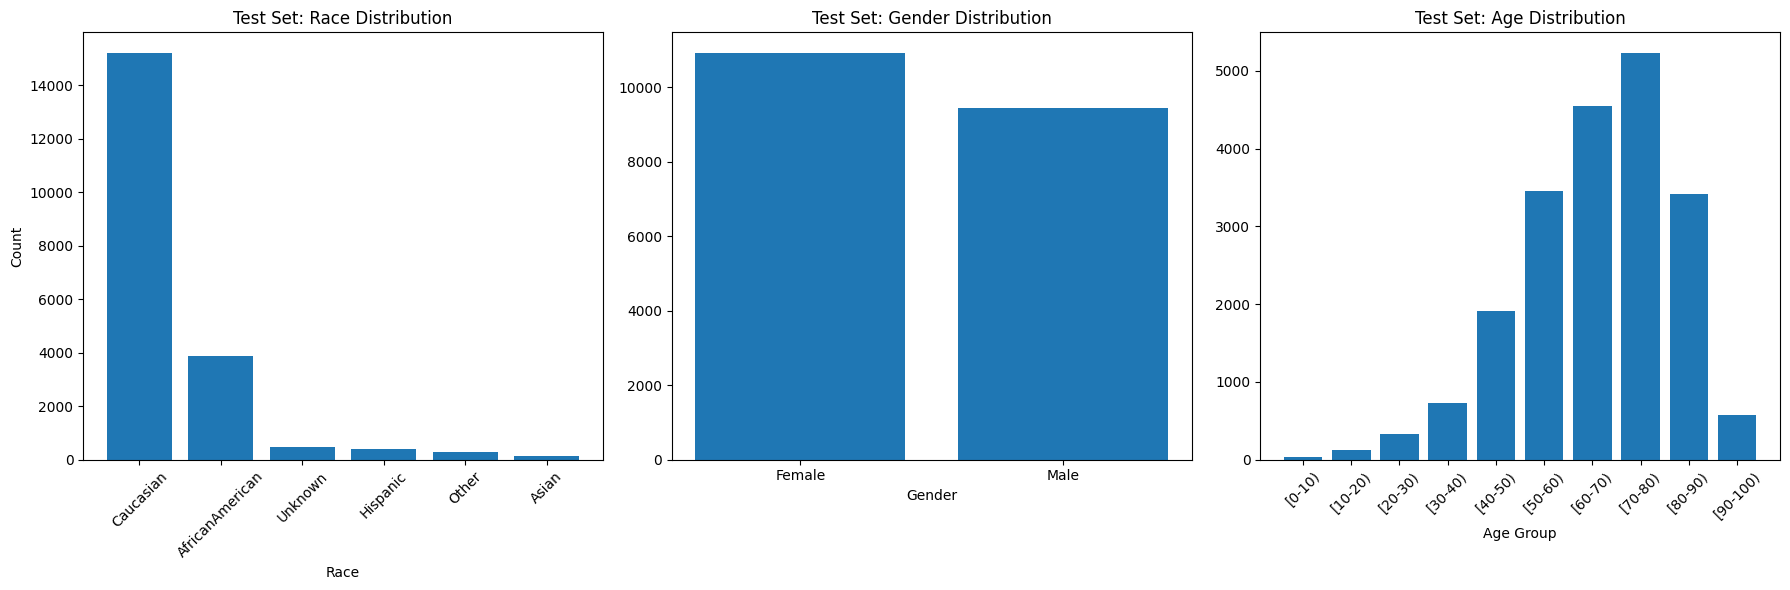

In [5]:
# Demographic Distribution Visualisation

import os

# Decode the sensitive attributes back to readable labels
race_labels = le_dict['race'].classes_
gender_labels = le_dict['gender'].classes_
age_labels = le_dict['age'].classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Race distribution
race_counts = sensitive_test['race'].value_counts()
axes[0].bar(race_counts.index, race_counts.values)
axes[0].set_title('Test Set: Race Distribution')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Gender distribution
gender_counts = sensitive_test['gender'].value_counts()
axes[1].bar(gender_counts.index,
            gender_counts.values)
axes[1].set_title('Test Set: Gender Distribution')
axes[1].set_xlabel('Gender')

# Age distribution
age_counts = sensitive_test['age'].value_counts().sort_index()
axes[2].bar(age_counts.index, age_counts.values)
axes[2].set_title('Test Set: Age Distribution')
axes[2].set_xlabel('Age Group')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

plt.savefig('images/demographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

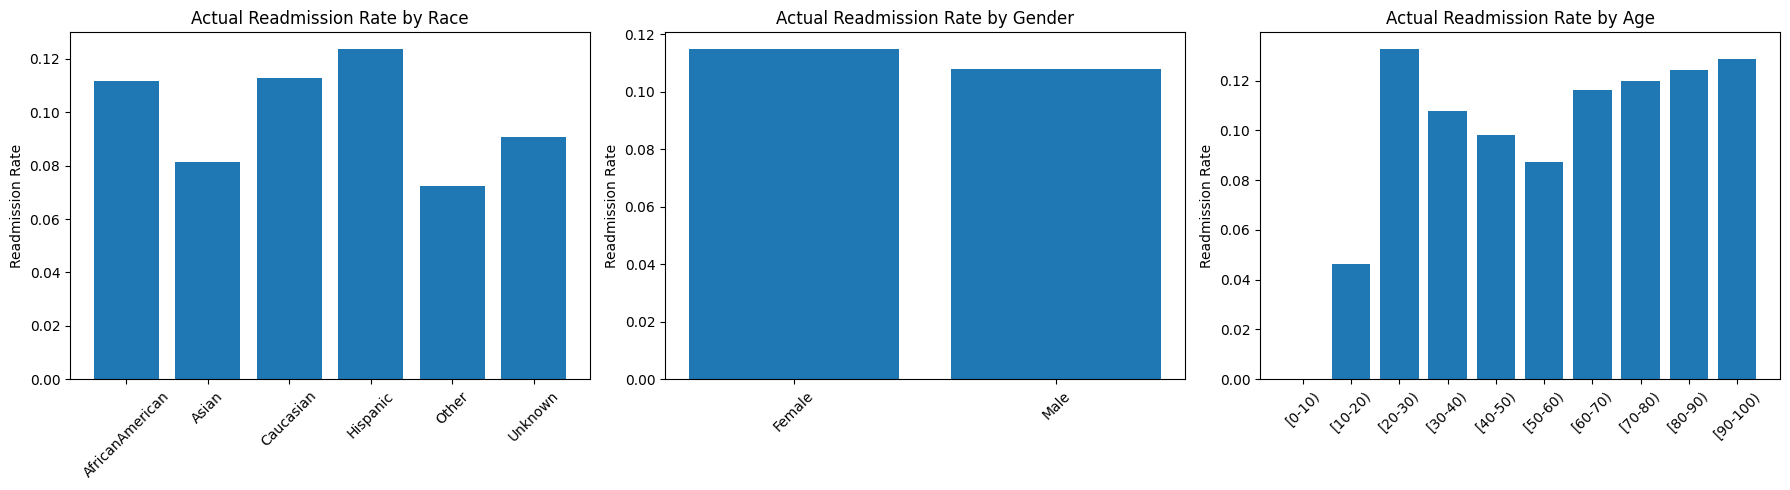

In [6]:
# Before looking at model predictions, check actual readmission rates
# This tells you if disparity exists in the data itself

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sensitive_with_labels = sensitive_test.copy()
sensitive_with_labels['true_label'] = y_test.values

for ax, col, labels in zip(axes,
                            ['race', 'gender', 'age'],
                            [race_labels, gender_labels, age_labels]):
    rates = sensitive_with_labels.groupby(col)['true_label'].mean()
    ax.bar(rates.index, rates.values)
    ax.set_title(f'Actual Readmission Rate by {col.title()}')
    ax.set_ylabel('Readmission Rate')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/actual_readmission_by_group.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Install and introduce Fairlearn
from fairlearn.metrics import (MetricFrame, selection_rate,
                                false_negative_rate, false_positive_rate,
                                equalized_odds_difference,
                                demographic_parity_difference)
from fairlearn.metrics import count

print("Fairlearn loaded successfully")

Fairlearn loaded successfully



SELECTION RATE BY RACE
race
AfricanAmerican    0.005691
Asian              0.000000
Caucasian          0.004073
Hispanic           0.000000
Other              0.000000
Unknown            0.000000
Name: selection_rate, dtype: float64
Overall: 0.0041
Demographic Parity Difference: 0.0057


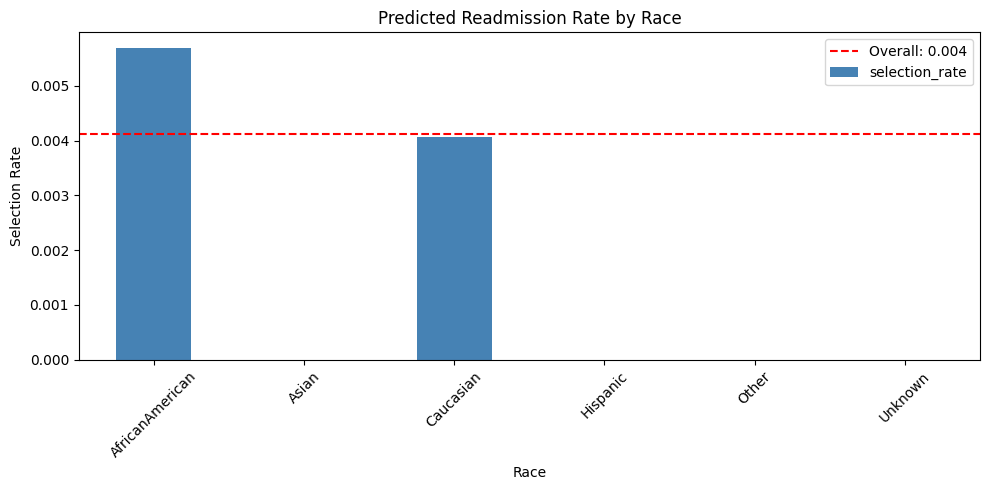


SELECTION RATE BY GENDER
gender
Female    0.004669
Male      0.003499
Name: selection_rate, dtype: float64
Overall: 0.0041
Demographic Parity Difference: 0.0012


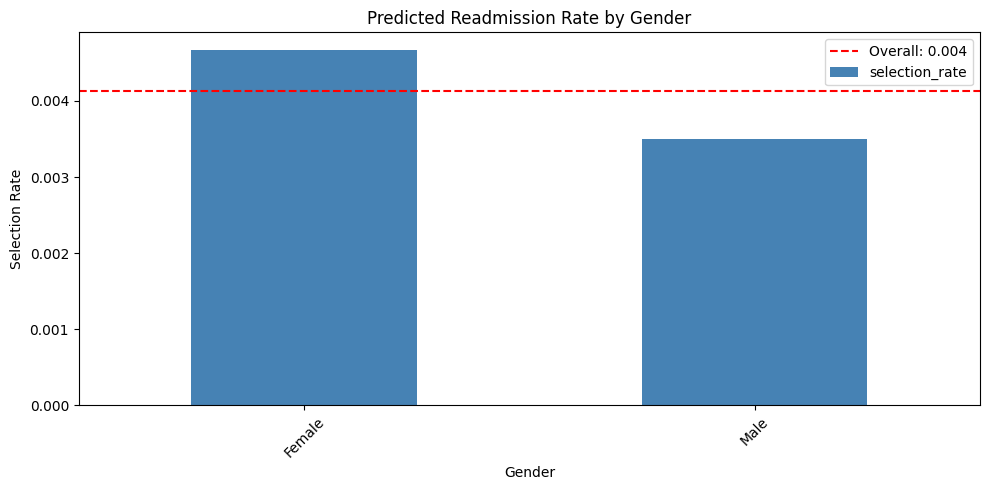


SELECTION RATE BY AGE
age
[0-10)      0.000000
[10-20)     0.000000
[20-30)     0.046296
[30-40)     0.012414
[40-50)     0.008364
[50-60)     0.003760
[60-70)     0.003299
[70-80)     0.002293
[80-90)     0.001172
[90-100)    0.000000
Name: selection_rate, dtype: float64
Overall: 0.0041
Demographic Parity Difference: 0.0463


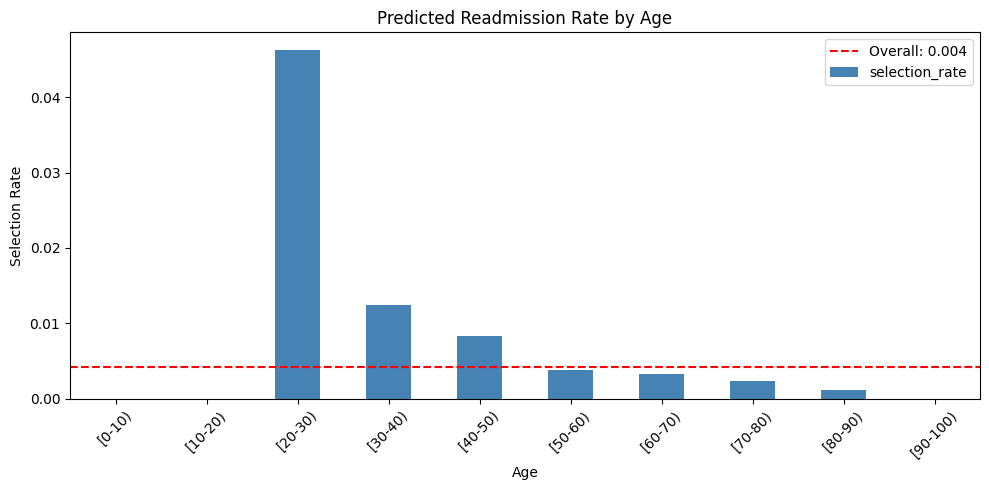

In [8]:
# Demographic Parity: Selection Rate by Group
# Selection rate = proportion of patients the model flags as readmitted

for sensitive_col, labels in [('race', race_labels),
                               ('gender', gender_labels),
                               ('age', age_labels)]:

    # sensitive_test[sensitive_col] already contains the readable string labels
    # No need to map using labels[x] which causes an IndexError
    sensitive_feature = sensitive_test[sensitive_col]

    mf = MetricFrame(
        metrics=selection_rate,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_feature
    )

    print(f"\n{'='*50}")
    print(f"SELECTION RATE BY {sensitive_col.upper()}")
    print(f"{'='*50}")
    print(mf.by_group)
    print(f"Overall: {mf.overall:.4f}")
    print(f"Demographic Parity Difference: "
          f"{demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature):.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    mf.by_group.plot(kind='bar', ax=ax, color='steelblue')
    ax.axhline(y=mf.overall, color='red', linestyle='--',
               label=f'Overall: {mf.overall:.3f}')
    ax.set_title(f'Predicted Readmission Rate by {sensitive_col.title()}')
    ax.set_ylabel('Selection Rate')
    ax.set_xlabel(sensitive_col.title())
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f'images/selection_rate_by_{sensitive_col}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


EQUALISED ODDS BY RACE
                 true_positive_rate  false_positive_rate  false_negative_rate
race                                                                         
AfricanAmerican              0.0255               0.0032               0.9745
Asian                        0.0000               0.0000               1.0000
Caucasian                    0.0210               0.0019               0.9790
Hispanic                     0.0000               0.0000               1.0000
Other                        0.0000               0.0000               1.0000
Unknown                      0.0000               0.0000               1.0000


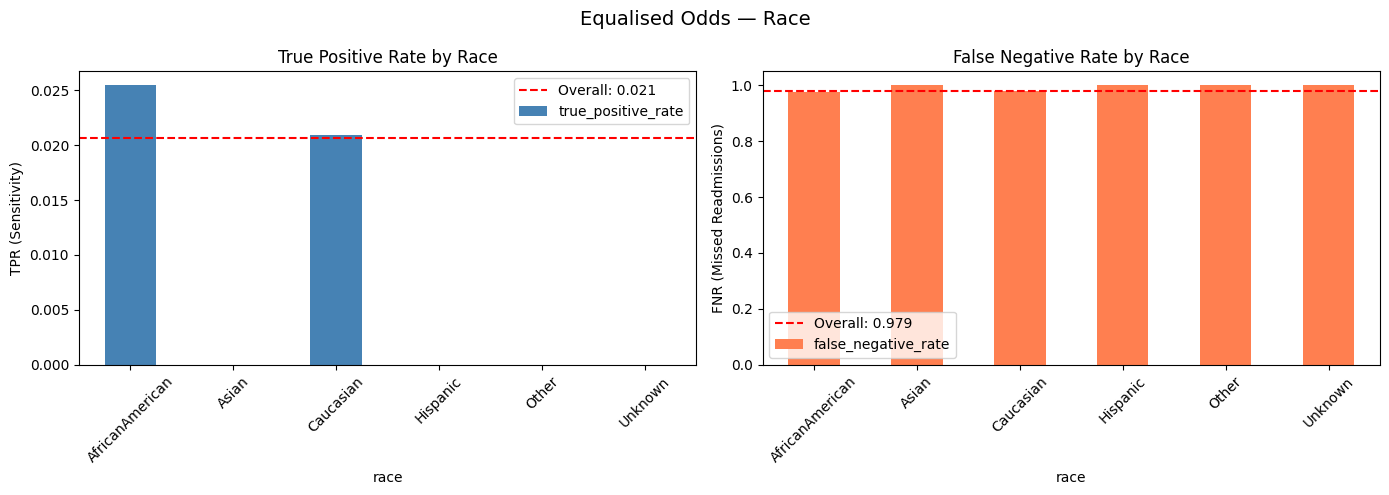


EQUALISED ODDS BY GENDER
        true_positive_rate  false_positive_rate  false_negative_rate
gender                                                              
Female              0.0231               0.0023               0.9769
Male                0.0177               0.0018               0.9823


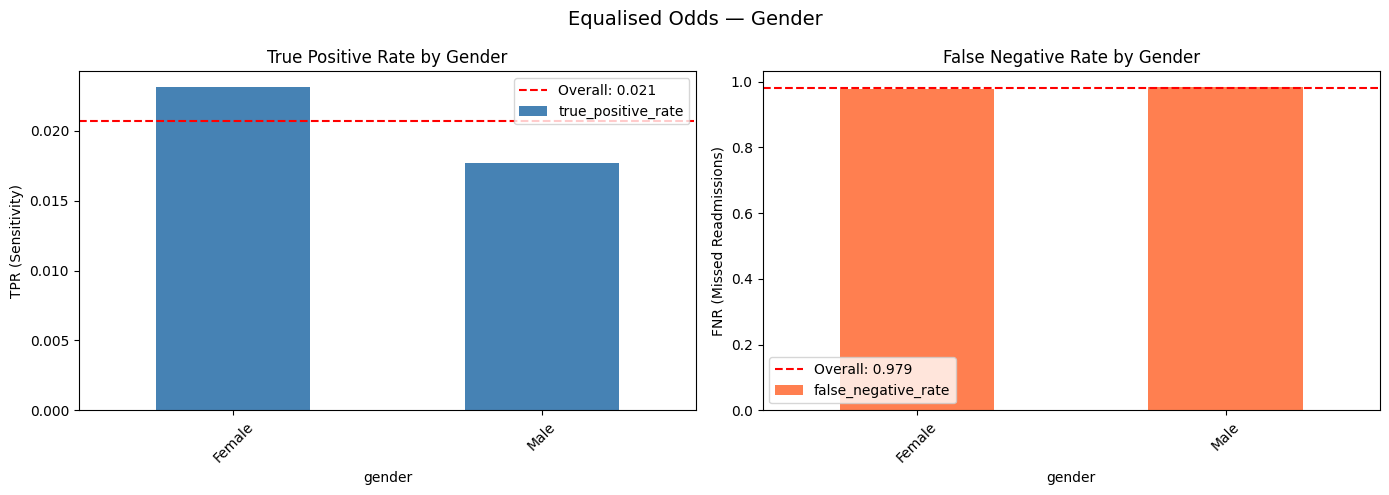


EQUALISED ODDS BY AGE
          true_positive_rate  false_positive_rate  false_negative_rate
age                                                                   
[0-10)                0.0000               0.0000               0.0000
[10-20)               0.0000               0.0000               1.0000
[20-30)               0.2093               0.0214               0.7907
[30-40)               0.0513               0.0077               0.9487
[40-50)               0.0426               0.0046               0.9574
[50-60)               0.0266               0.0016               0.9734
[60-70)               0.0170               0.0015               0.9830
[70-80)               0.0096               0.0013               0.9904
[80-90)               0.0071               0.0003               0.9929
[90-100)              0.0000               0.0000               1.0000


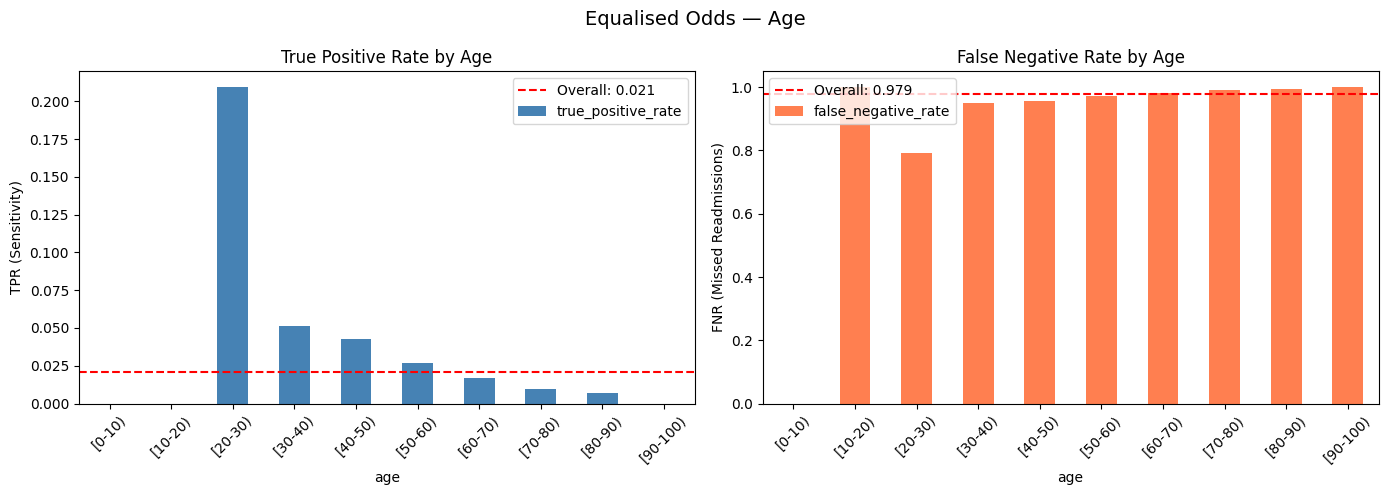

In [9]:
# Equalised Odds: TPR and FPR by Group

from sklearn.metrics import recall_score  # TPR = recall

for sensitive_col, labels in [('race', race_labels),
                               ('gender', gender_labels),
                               ('age', age_labels)]:

    # sensitive_test[sensitive_col] already contains the readable string labels
    # No need to map using labels[x] which causes an IndexError
    sensitive_feature = sensitive_test[sensitive_col]

    mf = MetricFrame(
        metrics={
            'true_positive_rate': recall_score,
            'false_positive_rate': false_positive_rate,
            'false_negative_rate': false_negative_rate,
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_feature
    )

    print(f"\n{'='*50}")
    print(f"EQUALISED ODDS BY {sensitive_col.upper()}")
    print(f"{'='*50}")
    print(mf.by_group.round(4))

    # Plot TPR and FPR side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    mf.by_group['true_positive_rate'].plot(
        kind='bar', ax=axes[0], color='steelblue')
    axes[0].axhline(y=mf.overall['true_positive_rate'],
                    color='red', linestyle='--',
                    label=f"Overall: {mf.overall['true_positive_rate']:.3f}")
    axes[0].set_title(f'True Positive Rate by {sensitive_col.title()}')
    axes[0].set_ylabel('TPR (Sensitivity)')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)

    mf.by_group['false_negative_rate'].plot(
        kind='bar', ax=axes[1], color='coral')
    axes[1].axhline(y=mf.overall['false_negative_rate'],
                    color='red', linestyle='--',
                    label=f"Overall: {mf.overall['false_negative_rate']:.3f}")
    axes[1].set_title(f'False Negative Rate by {sensitive_col.title()}')
    axes[1].set_ylabel('FNR (Missed Readmissions)')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Equalised Odds — {sensitive_col.title()}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'images/equalized_odds_{sensitive_col}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


FALSE NEGATIVE RATE DISPARITY SUMMARY
(High FNR = model missing actual readmissions for this group)


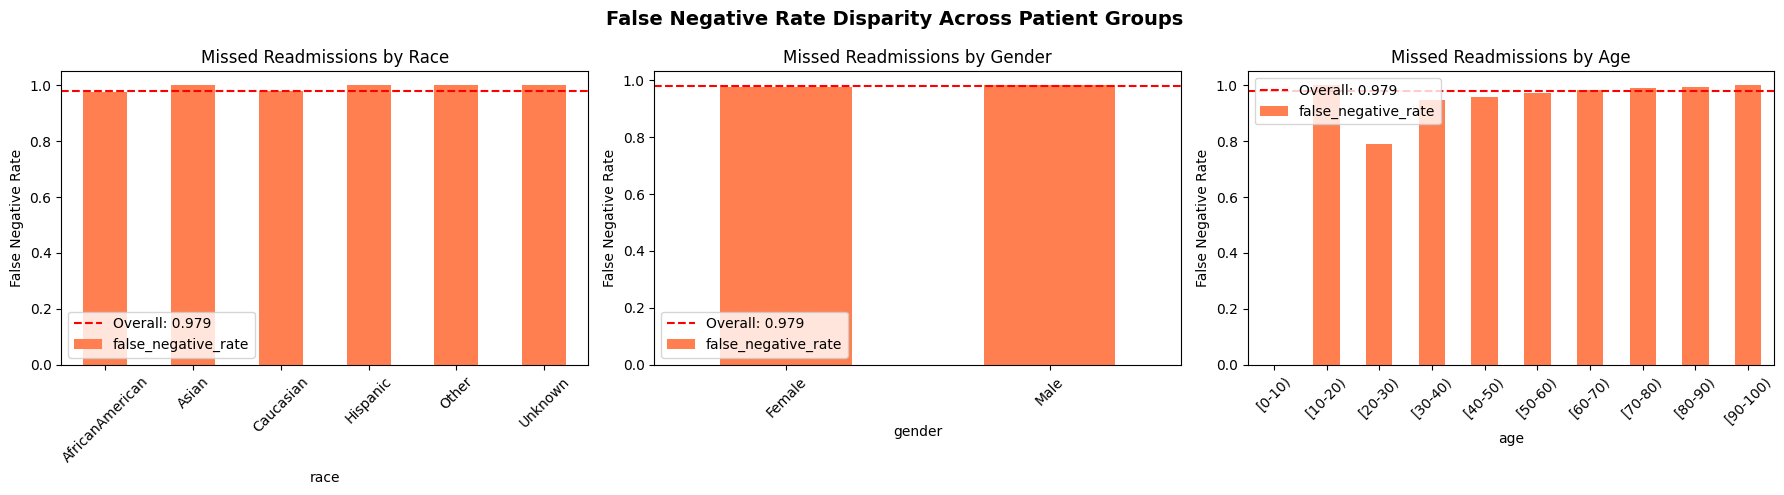

In [10]:
# False Negative Rate Disparity Summary
print("\n" + "="*60)
print("FALSE NEGATIVE RATE DISPARITY SUMMARY")
print("(High FNR = model missing actual readmissions for this group)")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sensitive_col, labels in zip(axes,
                                      ['race', 'gender', 'age'],
                                      [race_labels, gender_labels, age_labels]):

    # sensitive_test[sensitive_col] already contains the readable string labels
    # No need to map using labels[x] which causes an IndexError
    sensitive_feature = sensitive_test[sensitive_col]

    mf = MetricFrame(
        metrics=false_negative_rate,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_feature
    )

    mf.by_group.plot(kind='bar', ax=ax, color='coral')
    ax.axhline(y=mf.overall, color='red', linestyle='--',
               label=f'Overall: {mf.overall:.3f}')
    ax.set_title(f'Missed Readmissions by {sensitive_col.title()}')
    ax.set_ylabel('False Negative Rate')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('False Negative Rate Disparity Across Patient Groups',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fnr_disparity.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Use race as the primary sensitive attribute for mitigation
sensitive_feature_train = df_sensitive.loc[X_train.index, 'race']

# Mitigator wraps a base model and applies fairness constraints
base_model = LogisticRegression(max_iter=1000, random_state=42)
mitigator = ExponentiatedGradient(
    base_model,
    constraints=EqualizedOdds()
)

# Note: mitigator works on unscaled, unsmoted training data
mitigator.fit(X_train, y_train,
              sensitive_features=sensitive_feature_train)

# Predictions from mitigated model
y_pred_mitigated = mitigator.predict(X_test)
sensitive_feature_test = sensitive_test['race']

print("Mitigated Model Results:")
print(f"Accuracy: {(y_pred_mitigated == y_test).mean():.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_mitigated):.4f}")

Mitigated Model Results:
Accuracy: 0.8884
AUC-ROC: 0.5054



FAIRNESS-ACCURACY TRADE-OFF SUMMARY
Metric                                Original  Mitigated
------------------------------------------------------------
Accuracy                                0.8889     0.8884
Demographic Parity Difference           0.0057     0.0081

Note: Lower Demographic Parity Difference = fairer model
Accuracy trade-off shows the cost of improving fairness


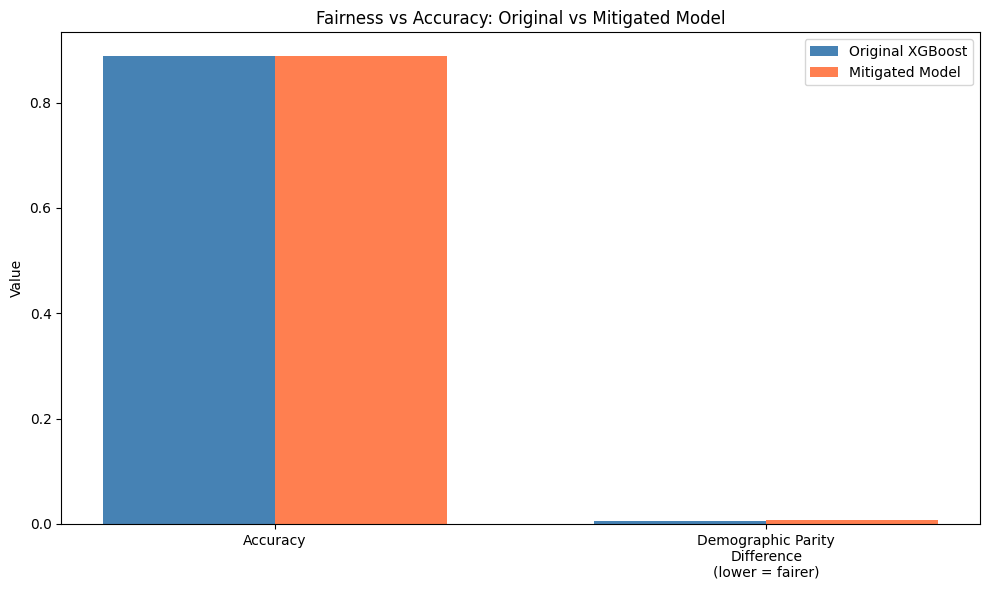

In [13]:
# Original Vs Mitigated Comparison
from fairlearn.metrics import demographic_parity_difference

# Original model metrics
dp_original = demographic_parity_difference(
    y_test, y_pred, sensitive_features=sensitive_feature_test)
acc_original = (y_pred == y_test).mean()

# Mitigated model metrics
dp_mitigated = demographic_parity_difference(
    y_test, y_pred_mitigated,
    sensitive_features=sensitive_feature_test)
acc_mitigated = (y_pred_mitigated == y_test).mean()

print("\n" + "="*60)
print("FAIRNESS-ACCURACY TRADE-OFF SUMMARY")
print("="*60)
print(f"{'Metric':<35} {'Original':>10} {'Mitigated':>10}")
print("-"*60)
print(f"{'Accuracy':<35} {acc_original:>10.4f} {acc_mitigated:>10.4f}")
print(f"{'Demographic Parity Difference':<35} {dp_original:>10.4f} {dp_mitigated:>10.4f}")
print("="*60)
print("\nNote: Lower Demographic Parity Difference = fairer model")
print("Accuracy trade-off shows the cost of improving fairness")

# Visualise the trade-off
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Accuracy', 'Demographic Parity\nDifference\n(lower = fairer)']
original_vals = [acc_original, abs(dp_original)]
mitigated_vals = [acc_mitigated, abs(dp_mitigated)]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, original_vals, width,
               label='Original XGBoost', color='steelblue')
bars2 = ax.bar(x + width/2, mitigated_vals, width,
               label='Mitigated Model', color='coral')

ax.set_title('Fairness vs Accuracy: Original vs Mitigated Model')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('images/mitigation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Full audit summary printout
print("\n" + "="*60)
print("COMPLETE FAIRNESS AUDIT SUMMARY")
print("="*60)

for sensitive_col, labels in [('race', race_labels),
                               ('gender', gender_labels),
                               ('age', age_labels)]:
    # sensitive_test[sensitive_col] already contains the readable string labels
    # No need to map using labels[x] which causes an IndexError
    sensitive_feature = sensitive_test[sensitive_col]

    dp_diff = demographic_parity_difference(
        y_test, y_pred, sensitive_features=sensitive_feature)
    eq_odds = equalized_odds_difference(
        y_test, y_pred, sensitive_features=sensitive_feature)

    print(f"\n{sensitive_col.upper()}")
    print(f"  Demographic Parity Difference: {dp_diff:.4f}")
    print(f"  Equalised Odds Difference:     {eq_odds:.4f}")
    print(f"  Interpretation: {'⚠️ Significant disparity' if abs(eq_odds) > 0.1 else '✅ Within acceptable range'}")

print("\n" + "="*60)
print("Note: Values closer to 0 indicate fairer model behaviour")
print("="*60)


COMPLETE FAIRNESS AUDIT SUMMARY

RACE
  Demographic Parity Difference: 0.0057
  Equalised Odds Difference:     0.0255
  Interpretation: ✅ Within acceptable range

GENDER
  Demographic Parity Difference: 0.0012
  Equalised Odds Difference:     0.0054
  Interpretation: ✅ Within acceptable range

AGE
  Demographic Parity Difference: 0.0463
  Equalised Odds Difference:     0.2093
  Interpretation: ⚠️ Significant disparity

Note: Values closer to 0 indicate fairer model behaviour
